# 04. 研究分野を「地図」として俯瞰する

このノートブックは、**01 が保存した論文データ (`data/works/bacteria/works.parquet`) を読むだけ**で、バクテリオファージ（細菌に感染するウイルス）研究という一つの分野の**全体地図**を描きます。

サイエンス・オブ・サイエンス（科学を科学する研究）では、分野の中身を2つの見方で捉えます。

- **引用のつながり**（誰が誰の研究を踏まえているか）＝ ネットワーク
- **内容の近さ**（何について書いているか）＝ テキスト

この2枚の地図を作って見比べるのがゴールです。

## 流れ
1. **引用ネットワーク**（§2）: 論文Aが論文Bを引用していれば線でつなぐ。
2. **コミュニティ検出**（§3, Leiden法）: 引用が密なかたまり＝サブ分野に自動で分ける。
3. **サブ分野の命名**（§4): 各かたまりを特徴づける語を抽出（任意で GPT が短い分野名を付ける）。
4. **俯瞰地図**（§5, UMAP): 論文の内容を2次元の点に落とし、サブ分野ごとに色分け。
5. **ネットワーク vs 内容**（§5.5): 2つの見方がどれだけ一致するかを並べて比較。
6. **サブ分野の要約 / 機関分析**（§5.6, §6): 注目テーマを GPT で要約し、特定機関の強みを地図で見る。

> 用語: **ノード**＝点（論文）、**エッジ**＝線（引用関係）、**クラスタ／コミュニティ**＝密につながった論文のかたまり（＝サブ分野）。

### 準備1: 実行環境をそろえる

ローカルの Jupyter でも Google Colab でも同じコードが動くよう、環境差を最初に吸収します。Colab のときだけライブラリを入れてリポジトリを取得し、`data/` のある場所へ移動します。あわせて、必要データが無ければ GitHub Release から自動ダウンロードする関数 `ensure_data` を定義します（この時点では定義するだけ）。

In [ ]:
# === セットアップ（このセルを最初に実行）===
# ローカル(Jupyter): 依存の確認と作業ディレクトリの調整のみ。
# Google Colab   : 依存インストール＋リポジトリ取得も自動で行う。
import os, sys

os.environ['OPENAI_API_KEY'] = 'sk-XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX'  # OpenAI API Key をここに貼る（ChatGPT/GPT-4の埋め込みを使う場合のみ必要）

# データを変更して他ノートと共有・永続化したい人だけ True に（Google Drive をマウントします）。
# False（既定）なら使い捨てランタイム内で完結し、必要データは GitHub Release から取得します（権限プロンプト不要・完全ワンクリック）。
USE_DRIVE = False

if 'google.colab' in sys.modules:
    !pip -q install requests pandas pyarrow numpy matplotlib scikit-learn scipy powerlaw networkx igraph leidenalg umap-learn gender-guesser iso4 nltk openai
    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')                      # Trueにした人だけ Drive 権限を承認（各自のDrive・同名でOK）
        BASE = '/content/drive/MyDrive/sciscitutorial'     # ノート間・セッション間でデータを永続共有
    else:
        BASE = '/content/sciscitutorial'                   # 使い捨てランタイム内。権限不要（データはRelease/APIから）
    if not os.path.exists(f'{BASE}/.git'):
        !git clone -q https://github.com/asatani/sciscitutorial.git {BASE}
    os.chdir(BASE)

# code/ から起動した場合はプロジェクトルート（data/ がある場所）へ移動する。
if os.path.basename(os.getcwd()) == 'code':
    os.chdir('..')

# 事前計算済みデータが無ければ GitHub Release から取得し data/ 以下に展開する。
# works=対象トピックの論文, career=03 §3-2 用のランダム著者, supplementary=06(DI)用のエッジリスト。
def ensure_data(name, works=False, career=False, supplementary=False):
    import urllib.request, zipfile
    RELEASE = 'https://github.com/asatani/sciscitutorial/releases/download/data-v1'
    needs = []
    if works:         needs.append((f'data/works/{name}', f'works_{name}.zip'))
    if career:        needs.append(('data/career', 'career.zip'))
    if supplementary: needs.append(('data/supplementary', 'supplementary.zip'))
    os.makedirs('data', exist_ok=True)
    for path, asset in needs:
        if os.path.exists(path):
            continue
        print('downloading', asset, '...')
        zip_path = f'data/{asset}'
        urllib.request.urlretrieve(f'{RELEASE}/{asset}', zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extractall('data')
        os.remove(zip_path)


### 準備2: ライブラリと設定

分析で使うライブラリを読み込み、**対象データセットや出力先などの設定を1か所にまとめます**。ここを変えるだけで対象分野を切り替えられます。

- `networkx`＝引用ネットワークを作る / `igraph`+`leidenalg`＝高速なコミュニティ検出 / `umap`＝高次元を2次元へ圧縮 / `sklearn`＝TF-IDF・次元圧縮・KMeans。
- `NAME='bacteria'` を `'qc'` にすると量子情報分野に丸ごと切り替わります。
- OpenAI のキーは環境変数 `OPENAI_API_KEY` から読み、未設定ならGPTを使うセルは自動でスキップします。

In [2]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
import leidenalg
import umap
import matplotlib.patheffects as patheffects
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'legend.frameon': False,
})
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
pd.set_option('display.max_columns', 100)

# --- データセット選択（'bacteria'=T11048 / 'qc'=T10020）---
NAME      = 'bacteria'              # ← 'qc' に変えれば量子データセットに切替
DATA_DIR  = f'data/works/{NAME}'
OUT_DIR   = f'output/{NAME}'
GPT_MODEL = 'gpt-5.4-mini'          # クラスタ命名(§4)・クラスタ要約(§5.6)に使うモデル
ensure_data(NAME, works=True)
os.makedirs(OUT_DIR, exist_ok=True)
# OpenAI APIキーは環境変数 OPENAI_API_KEY から読み込みます（未設定なら該当セルはスキップ）。
# os.environ['OPENAI_API_KEY'] = 'sk-...'


/Users/kimitaka/Desktop/sciscitutorial-main/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. データを読み込む

分析の出発点として、論文テーブル `works.parquet` を読み込みます。このファイルは**被引用数の多い順に並んでいる**ので、先頭から `NET_WORKS` 件を取るだけで「よく引用された論文」を選べます（並べ替え不要）。

> `NET_WORKS` は対象件数の上限です。既定値は大きく設定してあり、この分野（約11万件）では**実質すべての論文**が対象になります。小さくすると計算は速く・地図は疎に、大きくすると網羅的になります。

In [3]:
# 俯瞰地図は被引用上位コアに絞る。全件(約10万)だと直接引用が密なハブになり
# 地図が解釈しづらいため、まとまりの見やすい上位コアだけを対象にする。
# （works.parquet は被引用降順なので先頭 NET_WORKS 件を取るだけ）
NET_WORKS = 300000
works_df = pd.read_parquet(f'{DATA_DIR}/works.parquet').head(NET_WORKS).reset_index(drop=True)
print('network works:', len(works_df), '| year',
      int(works_df['publication_year'].min()), '-', int(works_df['publication_year'].max()))
works_df[['short_id', 'title', 'publication_year', 'cited_by_count', 'n_refs']].head()

network works: 109897 | year 1753 - 2024


,short_id,title,publication_year,cited_by_count,n_refs
0,W2100837269,Cleavage of Structural Proteins during the Ass...,1970,251645,21
1,W2138270253,DNA sequencing with chain-terminating inhibitors,1977,69307,12
2,W2028622989,Improved M13 phage cloning vectors and host st...,1985,15166,38
3,W2019410656,A rapid alkaline extraction procedure for scre...,1979,14877,20
4,W2128114769,Genome sequencing in microfabricated high-dens...,2005,7709,21


**結果の見方**: `network works: N | year A - B` は、対象にした論文が N 件、収録年が A〜B 年という意味です。下の表は先頭5件のプレビューで、`short_id`（W で始まる論文ID）・タイトル・出版年・被引用数・参考文献数 `n_refs` が並びます。被引用トップに古い古典的論文が来ていれば、被引用降順に並んでいる証拠です。

## 2. 引用ネットワークを作る

科学は先行研究を引用して積み上がります。「論文Aが論文Bを引用した」という関係を線でつなぐと、引用し合う論文どうしが密集した**かたまり（＝研究テーマ）**が見えてきます。

このセルでは、対象論文の**内部で完結する引用関係だけ**を線にして、地図の骨格になる引用ネットワークを組み立てます。引用の向き（どちらが引いたか）は使わず「つながっているか」だけを見ます（無向グラフ）。

In [4]:
ids = set(works_df['id'])

# 直接引用: コア集合内の論文が、同じくコア集合内の文献を引用していればエッジを張る。
G = nx.Graph()
G.add_nodes_from(ids)
for wid, refs in zip(works_df['id'], works_df['referenced_works']):
    for r in set(refs):
        if r in ids and r != wid:
            if G.has_edge(wid, r):
                G[wid][r]['weight'] += 1   # 相互引用なら weight=2
            else:
                G.add_edge(wid, r, weight=1)

main = G.subgraph(max(nx.connected_components(G), key=len)).copy()   # 最大連結成分だけ残す
print('graph:', G.number_of_nodes(), 'nodes,', G.number_of_edges(), 'edges | main component:', main.number_of_nodes())


graph: 109897 nodes, 846257 edges | main component: 61217


**結果の見方**: `graph: N nodes, M edges | main component: K` は、点(論文)N・線(引用)M のうち、**互いに引用でたどれる最大のかたまり（最大連結成分）が K 件**という意味です。引用でつながらない孤立した小さな断片は落とし、この主要なかたまり K 件だけを次のコミュニティ検出にかけます。

## 3. サブ分野に分ける（Leiden法）

引用ネットワークを、**内部で密につながった論文グループ（＝サブ分野）**に自動で分割します。Leiden 法は「線で強く結ばれた点を同じグループにまとめる」代表的なコミュニティ検出アルゴリズムです。

速度のため `networkx` のグラフを `igraph` に変換してから実行します。

In [5]:
nodes = sorted(main.nodes())        # ノード順を固定（乱択で順序が変わるとLeidenの結果もブレるため）
idx = {n: i for i, n in enumerate(nodes)}
g = ig.Graph(n=len(nodes), edges=[(idx[u], idx[v]) for u, v in main.edges()], directed=False)
g.es['weight'] = [main[u][v]['weight'] for u, v in main.edges()]
# resolution_parameter が大きいほど細かく分割される（サブ分野の粒度）。seed で再現性を固定。
partition = leidenalg.find_partition(g, leidenalg.RBConfigurationVertexPartition,
                                     weights='weight', resolution_parameter=1.6, seed=42)
node_cluster = {nodes[i]: c for c, members in enumerate(partition) for i in members}
works_df['cluster'] = works_df['id'].map(node_cluster).fillna(-1).astype(int)
print('Leiden communities:', works_df[works_df['cluster'] >= 0]['cluster'].nunique())
display(works_df[works_df['cluster'] >= 0]['cluster'].value_counts().head(10))


Leiden communities: 39


cluster
0    5760
1    5326
2    4958
3    4317
4    4289
5    3916
6    3616
7    3171
8    2693
9    2270
Name: count, dtype: int64

**結果の見方**: `Leiden communities: C` は検出されたサブ分野の数です。下の一覧は各クラスタ（サブ分野）の論文数で、大きいものほど主要なテーマです。まだ番号（0,1,2…）が付いただけで、各テーマが「何の研究か」は次の §4 で語から読み解きます。

## 4. 各サブ分野を特徴づける語を抜き出す

番号だけのクラスタを人間に分かる形にするため、各サブ分野を**特徴づけるキーワード**を抽出します。

ポイントは **contrast（対比）方式**です。単純に頻度が高い語を選ぶと、どのクラスタでも "study" のような一般語ばかりになります。そこで「**そのクラスタの平均 − 全体の平均**」が大きい語＝**他クラスタより際立つ語**を選び、サブ分野の個性が出るようにします。

In [6]:
texts = (works_df['title'].fillna('') + ' ' + works_df['abstract'].fillna(''))
# この分野で頻出する一般語（ノイズ）を除外。'mml'/'math' はMathML由来のタグ。
stop = list(ENGLISH_STOP_WORDS) + ['phage', 'phages', 'bacteriophage', 'bacteria', 'bacterial',
        'virus', 'viral', 'viruses', 'using', 'based', 'new', 'mml', 'math', 'non',
        'results', 'present', 'study', 'paper']
tfidf = TfidfVectorizer(max_features=5000, stop_words=stop, min_df=2, ngram_range=(1, 2))
X = tfidf.fit_transform(texts)                 # X: TF-IDF 行列（後続の SVD/比較でも再利用）
terms = np.array(tfidf.get_feature_names_out())

# 識別命名: クラスタ平均 - 全体平均（contrast）が大きい語ほど、そのクラスタ固有。
# 単純なTF-IDF平均だと全クラスタで高い汎用語が並ぶので、「他クラスタより際立つ語」を上位に出す。
labeled = works_df[works_df['cluster'] >= 0]
global_mean = np.asarray(X[labeled.index].mean(axis=0)).ravel()

kw = []
for c, grp in labeled.groupby('cluster'):
    contrast = np.asarray(X[grp.index].mean(axis=0)).ravel() - global_mean
    kw.append({'cluster': c, 'works': len(grp), 'mean_year': round(grp['publication_year'].mean(), 1),
               'keywords': ', '.join(terms[np.argsort(contrast)[-8:][::-1]])})
kw_df = pd.DataFrame(kw).sort_values('works', ascending=False).reset_index(drop=True)
display(kw_df.head(15))

,cluster,works,mean_year,keywords
0,0,5760,1974.3,"t4, t2, t5, synthesis, typing, infected, mutan..."
1,1,5326,2014.9,"therapy, infections, bacteriophages, resistant..."
2,2,4958,1984.6,"lambda, mu, p1, p22, dna, coli, gene, repressor"
3,3,4317,2018.7,"virome, gut, diversity, metagenomic, communiti..."
4,4,4289,2005.4,"assembly, protein, capsid, self, mosaic, parti..."
5,5,3916,1991.4,"dna, filamentous, plasmid, m13, φx174, fd, sin..."
6,6,3616,2014.8,"salmonella, bacteriophages, food, biocontrol, ..."
7,7,3171,1991.6,"bacillus, subtilis, bacillus subtilis, dna, sp..."
8,8,2693,2008.1,"marine, abundance, sea, aquatic, microbial, al..."
9,9,2270,1994.6,"aureus, staphylococcus, p2, typing, staphyloco..."


**結果の見方**: `kw_df` は論文数の多い順のサブ分野一覧です。各行の `keywords` がそのクラスタで際立つ語で、例えば「治療・感染」「海洋・多様性」のように**テーマの輪郭**が読み取れます。`mean_year` は平均出版年で、新しめ／古めのテーマかの目安になります。

### サブ分野に短い名前を付ける（任意でGPT）

キーワードの羅列だと図の凡例が読みにくいので、各サブ分野に**短い分野名**を与えます。まずキーワード上位2語を仮の名前にしておき、`OPENAI_API_KEY` があれば GPT により自然な英語の分野名で上書きします（無ければ仮の名前のまま進むので、キー無しでも止まりません）。

In [7]:
import os, json
# まずフォールバックとして各クラスタの識別語 上位2語を名前にしておく（キー無しでも必ず埋まる）。
# OPENAI_API_KEY があれば GPT が付けた分野名で names を上書きする。
names = {
    int(r["cluster"]): ", ".join(str(r["keywords"]).split(", ")[:2])
    for _, r in kw_df.iterrows()
}
if os.getenv("OPENAI_API_KEY"):
    from openai import OpenAI

    prompt = (
        'Return a JSON object mapping cluster IDs to short English field names '
        '(maximum 5 words).\n'
        + "\n".join(
            f'{int(r["cluster"])}: {r["keywords"]}'
            for _, r in kw_df.iterrows()
        )
    )

    resp = OpenAI().chat.completions.create(
        model=GPT_MODEL,
        temperature=0,
        response_format={"type": "json_object"},
        messages=[{"role": "user", "content": prompt}],
    )

    result = json.loads(resp.choices[0].message.content)
    names.update({int(k): v for k, v in result.items()})
print(json.dumps(names, indent=2, ensure_ascii=False))

{
  "0": "Phage typing",
  "1": "Phage therapy",
  "2": "Lambda gene regulation",
  "3": "Gut virome diversity",
  "4": "Capsid self-assembly",
  "5": "Filamentous phage DNA",
  "6": "Food biocontrol phages",
  "7": "Bacillus subtilis phage",
  "8": "Marine cyanophages",
  "9": "Staphylococcus phage typing",
  "10": "Bacterial defense systems",
  "11": "Lactococcal dairy phages",
  "12": "DNA packaging motor",
  "13": "Endolysin enzymes",
  "14": "Archaeal thermophages",
  "15": "RNA phages",
  "16": "Mycobacteriophages",
  "17": "Cell surface layers",
  "19": "Giant viruses",
  "18": "Small RNAs",
  "20": "T7 RNA polymerase",
  "21": "Outer membrane proteins",
  "22": "Pseudomonas jumbo phages",
  "23": "Vaccinia transcription enzymes",
  "24": "Gene transfer",
  "25": "Mutagenesis methods",
  "26": "Tetrahymena cell division",
  "27": "Cell wall",
  "29": "SARS-CoV-2 spike",
  "28": "Antigen expression",
  "30": "Molecular simulation",
  "31": "Arginine metabolism",
  "32": "mRNA cle

**結果の見方**: 出力の `names` は「クラスタ番号 → 分野名」の対応です。キーがある実行では GPT が付けた分野名（例: `Phage therapy` など）、無い実行ではキーワード（例: `therapy, infections`）が入ります。この `names` は以降のすべての地図の凡例・注記で共通利用されます。

## 5. 俯瞰地図を描く（UMAP）

各論文を「内容を表す数値ベクトル」にし、それを**2次元に潰して地図の座標**にします。ここでは 02 で作った **OpenAI 埋め込み**（文の意味を捉えた 256 次元ベクトル）を使います。

`short_id` を鍵に埋め込みと論文を突き合わせ、**埋め込みがある論文だけ**に `works_df` をそろえます（以降 x,y 座標と行がずれないようにするため）。そのうえで UMAP を2回かけ、(1) 埋め込みそのもの → `x, y`、(2) 埋め込みを SVD で50次元に圧縮したもの → `x2, y2`、の2組の座標を作ります。

In [8]:
EMB_PATH = f'{DATA_DIR}/embeddings.npz'
z = np.load(EMB_PATH, allow_pickle=True)
nz = min(len(z['ids']), len(z['vecs']))            # 生成途中のnpzでも先頭nz件は整合
row_of = {sid: i for i, sid in enumerate(z['ids'][:nz].astype(str))}
pos = works_df['short_id'].map(row_of)             # works_df の各行 -> 埋め込み行番号（無ければNaN）

mask = pos.notna()                                 # 埋め込みがある行だけ
works_df = works_df[mask].reset_index(drop=True)   # works_df を整列（以降 x,y と行対応が保たれる）
pos = pos[mask].astype(int).to_numpy()

feats = z['vecs'][pos]                              # short_id で works_df に整列
print('features: OpenAI embeddings', feats.shape, f'(aligned by short_id, {mask.sum():,}/{len(mask):,} 件)')
feats2 = TruncatedSVD(50, random_state=42).fit_transform(feats)
print('features: embeddings + SVD', feats2.shape)

# UMAPで2次元に圧縮して works_df に x, y 座標を持たせる。
xy = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42).fit_transform(feats)
works_df['x'], works_df['y'] = xy[:, 0], xy[:, 1]

xy = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42).fit_transform(feats2)
works_df['x2'], works_df['y2'] = xy[:, 0], xy[:, 1]

features: OpenAI embeddings (30000, 256) (aligned by short_id, 30,000/109,897 件)
features: embeddings + SVD (30000, 50)


/Users/kimitaka/Desktop/sciscitutorial-main/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kimitaka/Desktop/sciscitutorial-main/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


**結果の見方**: `features: OpenAI embeddings (…件)` は、埋め込みが見つかって地図に載る論文数です。ここで `works_df` は埋め込みのある論文だけに絞られ、各論文に地図座標 `x,y`（埋め込み）と `x2,y2`（埋め込み+SVD）が付きました。次の2セルでこの座標に点を打ちます。

### 地図①: OpenAI 埋め込みベースの俯瞰図

`x, y`（埋め込みそのもの）に論文を打点し、主要サブ分野を色分けした地図を描きます。点の大きさは被引用数に比例（影響の大きい論文ほど大きく）、その他の論文は灰色の背景にします。各サブ分野の**最も点が密な場所**にラベルを置きます。

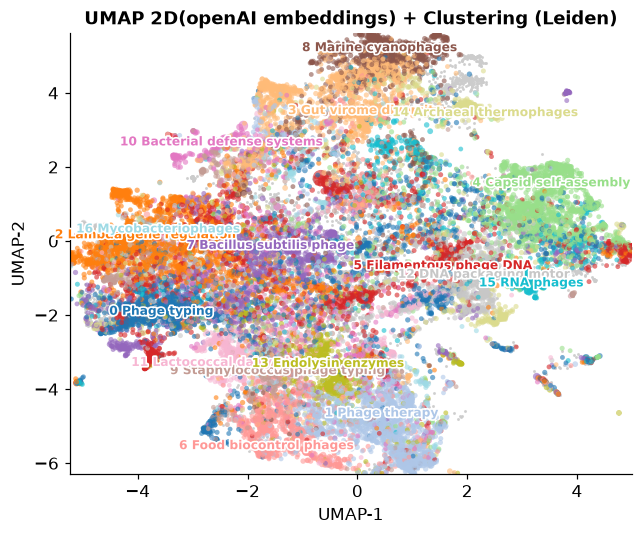

In [9]:
top = kw_df.head(17)['cluster'].astype(int).tolist()
xlo, xhi = np.percentile(works_df['x'], [0.3, 99.7])
ylo, yhi = np.percentile(works_df['y'], [0.3, 99.7])
# 点の大きさは被引用数に応じてスケール（影響の大きい論文ほど大きく）。
size = np.clip(8 + np.sqrt(works_df['cited_by_count'] + 1) / np.sqrt(works_df['cited_by_count'].max()) * 200, 8, 210)

fig, ax = plt.subplots(figsize=(6, 5))
other = works_df[~works_df['cluster'].isin(top)]
ax.scatter(other['x'], other['y'], s=1, c='0.8', alpha=0.8, rasterized=True)
cmap = plt.get_cmap('tab20', len(top))
works_df_ = works_df[works_df['cluster'].isin(top)]
ax.scatter(works_df_['x'], works_df_['y'], s=size[works_df_.index], color=[cmap(i) for i in works_df_['cluster'].astype(int)], alpha=0.6, linewidths=0, rasterized=True, label=names[c])

# ラベル位置: クラスタの点を10x10格子で数え、最も密なマスの中央値に置く（重なりや空白を避ける）。
for i, c in enumerate(top):
    s = works_df[works_df['cluster'] == c]
    xe = np.linspace(xlo, xhi, 11); ye = np.linspace(ylo, yhi, 11)
    H, _, _ = np.histogram2d(s['x'], s['y'], bins=[xe, ye])
    ix, iy = np.unravel_index(H.argmax(), H.shape)
    sub = s[(s['x'] >= xe[ix]) & (s['x'] < xe[ix+1]) & (s['y'] >= ye[iy]) & (s['y'] < ye[iy+1])]
    lx = sub['x'].median() if len(sub) else (xe[ix]+xe[ix+1])/2
    ly = sub['y'].median() if len(sub) else (ye[iy]+ye[iy+1])/2
    ax.annotate(f'{c} {names[c]}', (lx, ly), fontsize=8, fontweight='bold',
                color=cmap(i), ha='center', va='center', zorder=5,
                path_effects=[patheffects.withStroke(linewidth=2.2, foreground='white')])

ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi); ax.grid(False)
ax.set_title("UMAP 2D(openAI embeddings) + Clustering (Leiden)"); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/04_field_network_overview.pdf'); plt.show()

**結果の見方**: 近い点ほど「内容が似た論文」です。同じ色のかたまりが1つのサブ分野で、離れた色どうしは内容の遠いテーマ。中央付近で色が混ざる領域は、複数テーマにまたがる論文が多い"境界領域"と読めます。

### 地図②: 埋め込み＋SVD（次元圧縮）ベースの俯瞰図

同じ論文集合・同じ手順で、こんどは**埋め込みを SVD で50次元に圧縮した特徴量**（`x2, y2`）から地図を描きます。地図①と見比べると、次元圧縮によって「似ている」の捉え方がどう変わるかが分かります。

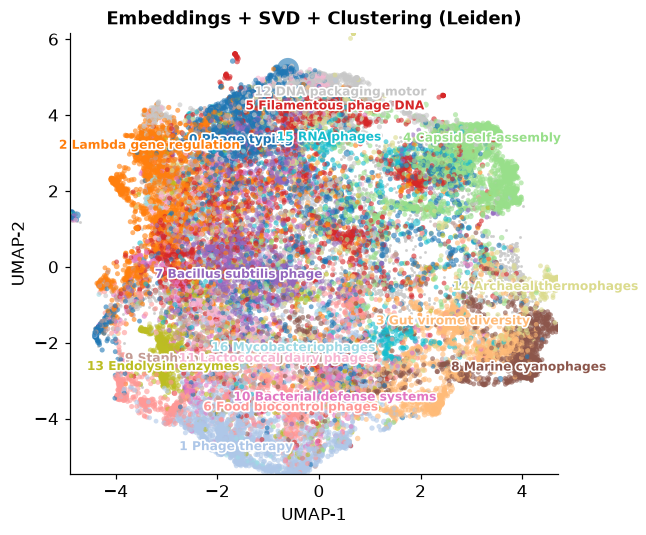

In [10]:
top = kw_df.head(17)['cluster'].astype(int).tolist()
xlo, xhi = np.percentile(works_df['x2'], [0.3, 99.7])
ylo, yhi = np.percentile(works_df['y2'], [0.3, 99.7])
# 点の大きさは被引用数に応じてスケール（影響の大きい論文ほど大きく）。
size = np.clip(8 + np.sqrt(works_df['cited_by_count'] + 1) / np.sqrt(works_df['cited_by_count'].max()) * 200, 8, 210)

fig, ax = plt.subplots(figsize=(6, 5))
other = works_df[~works_df['cluster'].isin(top)]
ax.scatter(other['x2'], other['y2'], s=1, c='0.8', alpha=0.8, rasterized=True)
cmap = plt.get_cmap('tab20', len(top))
works_df_ = works_df[works_df['cluster'].isin(top)]
ax.scatter(works_df_['x2'], works_df_['y2'], s=size[works_df_.index], color=[cmap(i) for i in works_df_['cluster'].astype(int)], alpha=0.6, linewidths=0, rasterized=True, label=names[c])

for i, c in enumerate(top):
    s = works_df[works_df['cluster'] == c]
    xe = np.linspace(xlo, xhi, 11); ye = np.linspace(ylo, yhi, 11)
    H, _, _ = np.histogram2d(s['x2'], s['y2'], bins=[xe, ye])
    ix, iy = np.unravel_index(H.argmax(), H.shape)
    sub = s[(s['x2'] >= xe[ix]) & (s['x2'] < xe[ix+1]) & (s['y2'] >= ye[iy]) & (s['y2'] < ye[iy+1])]
    lx = sub['x2'].median() if len(sub) else (xe[ix]+xe[ix+1])/2
    ly = sub['y2'].median() if len(sub) else (ye[iy]+ye[iy+1])/2
    ax.annotate(f'{c} {names[c]}', (lx, ly), fontsize=8, fontweight='bold',
                color=cmap(i), ha='center', va='center', zorder=5,
                path_effects=[patheffects.withStroke(linewidth=2.2, foreground='white')])

ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi); ax.grid(False)
ax.set_title("Embeddings + SVD + Clustering (Leiden)"); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/04_field_map_embeddings_svd.pdf'); plt.show()

**結果の見方**: 地図①（256次元の生の埋め込み）と比べ、SVD 圧縮版は大まかな構造を残しつつ細部がなだらかになりがちです。どちらでも上位クラスタは部分的にまとまりつつ広く混ざる、という全体像は共通します。使い分けの目安は、意味的な検索・推薦なら生の埋め込み、軽量に回したいなら圧縮版です。

## 5.5 「引用のつながり」と「内容の近さ」を並べて比べる

分野を俯瞰する見方は2つあります。

- **引用のつながり**: 直接引用グラフ + Leiden（§3のクラスタ）。「誰が誰を踏まえているか」という構造のまとまり。
- **内容の近さ**: テキスト特徴量を直接 KMeans でまとめたもの。「何について書いているか」という意味のまとまり。

**同じ UMAP 地図**を、左＝引用の色、右＝内容の色で塗り分けて並べます。点の位置は同じで色だけが変わるので、「同じ場所が両者で同じ色群になるか？」を直接見比べられます。

text clusters: 12 | silhouette: 0.023


text_cluster
t4, lambda               3390
gene, coli               3090
host, genome             3019
capsid, assembly         2994
bacillus, cell           2888
dna, rna                 2797
resistant, aeruginosa    2395
protein, structure       2025
Name: count, dtype: int64

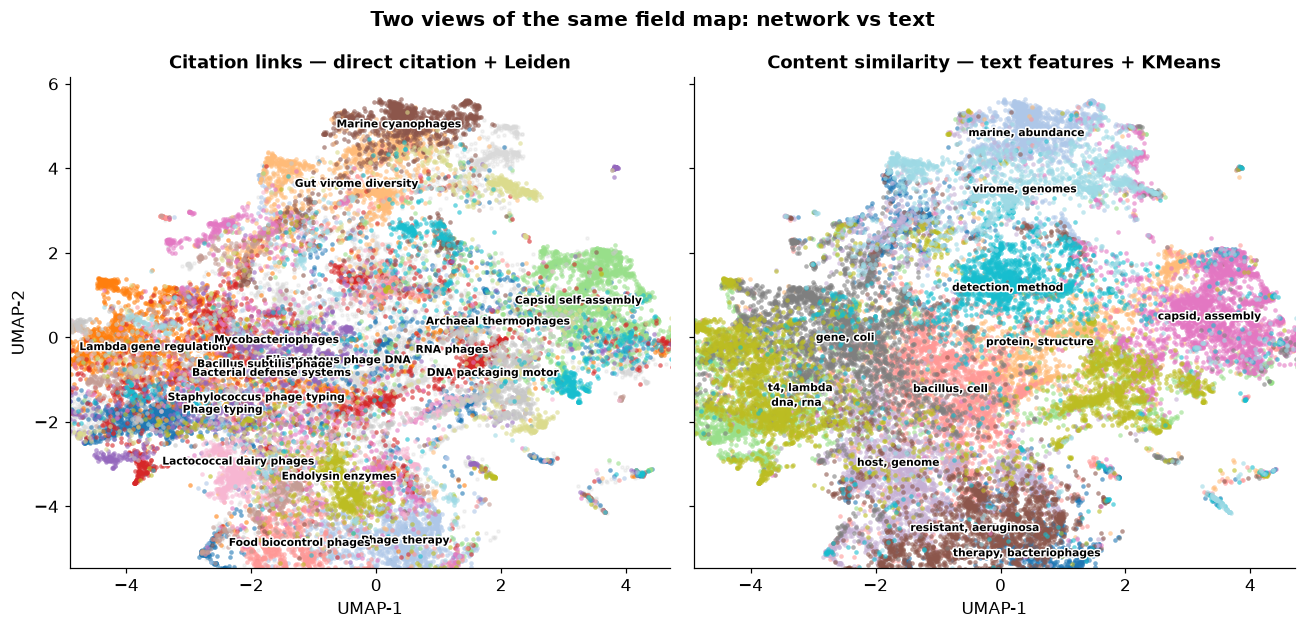

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# テキスト特徴量を直接 KMeans でまとめる（ネットワークの繋がりは一切使わない）。
N_TEXT = 12  # ネットワーク側のコミュニティ数と揃えて比較しやすくする。
works_df['text_cluster'] = KMeans(n_clusters=N_TEXT, random_state=42, n_init=10).fit_predict(feats)
print('text clusters:', N_TEXT, '| silhouette:', round(silhouette_score(feats, works_df['text_cluster']), 3))

# テキストクラスタにも識別キーワード（contrast）で短い名前を付ける（重心注記用）。
text_global_mean = np.asarray(X.mean(axis=0)).ravel()
tnames = {}
for c, grp in works_df.groupby('text_cluster'):
    contrast = np.asarray(X[grp.index].mean(axis=0)).ravel() - text_global_mean
    tnames[c] = ', '.join(terms[np.argsort(contrast)[-2:][::-1]])
display(works_df['text_cluster'].value_counts().rename(index=tnames).head(8))

# 同じUMAP座標を「ネットワーク色」と「テキスト色」で並べて見比べる。
fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), sharex=True, sharey=True)

# 左: 引用のつながり（直接引用 + Leiden）— §5の俯瞰地図と同じ色分け。
ax = axes[0]
ax.scatter(other['x'], other['y'], s=4, c='0.85', alpha=0.3, rasterized=True)
for i, c in enumerate(top):
    s = works_df[works_df['cluster'] == c]
    ax.scatter(s['x'], s['y'], s=9, color=cmap(i), alpha=0.6, linewidths=0, rasterized=True)
    ax.annotate(names[c], (s['x'].median(), s['y'].median()), fontsize=7, fontweight='bold', ha='center', va='center',
                path_effects=[patheffects.withStroke(linewidth=2, foreground='white')])
ax.set_title('Citation links — direct citation + Leiden')

# 右: 内容の近さ（テキスト特徴量 + KMeans）。
ax = axes[1]
tcmap = plt.get_cmap('tab20', N_TEXT)
for c in range(N_TEXT):
    s = works_df[works_df['text_cluster'] == c]
    ax.scatter(s['x'], s['y'], s=9, color=tcmap(c), alpha=0.6, linewidths=0, rasterized=True)
    ax.annotate(tnames[c], (s['x'].median(), s['y'].median()), fontsize=7, fontweight='bold', ha='center', va='center',
                path_effects=[patheffects.withStroke(linewidth=2, foreground='white')])
ax.set_title('Content similarity — text features + KMeans')

for ax in axes:
    ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi); ax.grid(False); ax.set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')
fig.suptitle('Two views of the same field map: network vs text', fontsize=13, fontweight='bold')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/04_clustering_comparison.pdf'); plt.show()


**結果の見方**: `silhouette` はまとまりの分離度（高いほどくっきり）。左右で**同じ場所が同じ色群になる領域**＝引用と内容が一致する「閉じた研究コミュニティ」。**ずれる領域**＝手法や話題は共有しつつ、別々の系譜で引用され合う領域、と解釈できます。

## 5.6 注目サブ分野を GPT で要約（初期 vs 最近）

あるサブ分野の**被引用トップ論文を「初期」と「最近」に分けて**取り出し、「何のテーマで、初期から最近にかけてどう発展したか」を GPT に日本語で要約させます。分野の時間変化を素早くつかむ手順です。

初期／最近の境目は、そのクラスタの**出版年の中央値**にします（固定年ではなくクラスタごとに半々に分かれる）。`TARGET_CLUSTER` を変えれば任意のサブ分野を分析できます。

In [12]:
TARGET_CLUSTER = int(kw_df.iloc[0]['cluster'])   # 既定は最大クラスタ。任意のクラスタIDに変更可。
TOP_N = 10                                        # 初期・最近それぞれの取得件数。

cluster_df = works_df[works_df['cluster'] == TARGET_CLUSTER].copy()
mid_year = cluster_df['publication_year'].median()
pick = lambda d: d.sort_values('cited_by_count', ascending=False).head(TOP_N)
past = pick(cluster_df[cluster_df['publication_year'] <= mid_year]).sort_values('publication_year')
recent = pick(cluster_df[cluster_df['publication_year'] > mid_year]).sort_values('publication_year')
print(f"Cluster {TARGET_CLUSTER}: {names[TARGET_CLUSTER]} | {len(cluster_df)} papers "
      f"(初期<={int(mid_year)}: {len(past)}, 最近>{int(mid_year)}: {len(recent)})")
display(past[['publication_year', 'cited_by_count', 'title']])
display(recent[['publication_year', 'cited_by_count', 'title']])

fmt = lambda d: '\n'.join(
    f"- ({r.publication_year}, cited {r.cited_by_count}) {r.title}: {(r.abstract or '')[:200]}"
    for r in d.itertuples())
prompt = (f"以下は学術分野クラスタ「{names[TARGET_CLUSTER]}」の代表論文です。\n\n"
          f"【初期のトップ論文】\n{fmt(past)}\n\n"
          f"【最近のトップ論文】\n{fmt(recent)}\n\n"
          "このクラスタが何の研究テーマで、初期から最近にかけてどう発展したかを"
          "日本語で5〜7文で要約してください。専門用語は簡潔に。")

if os.getenv('OPENAI_API_KEY'):
    from openai import OpenAI
    resp = OpenAI().chat.completions.create(model=GPT_MODEL, messages=[{'role': 'user', 'content': prompt}])
    print('\n=== GPT summary (' + GPT_MODEL + ') ===\n' + resp.choices[0].message.content)
else:
    print('\n⚠ OPENAI_API_KEY 未設定。下記プロンプトをそのまま使えます:\n')
    print(prompt[:1200])


Cluster 0: Phage typing | 2246 papers (初期<=1973: 10, 最近>1973: 10)


,publication_year,cited_by_count,title
27,1949,2244,Antigen — Antibody Reactions In Gels
61,1952,1565,INDEPENDENT FUNCTIONS OF VIRAL PROTEIN AND NUC...
107,1953,1085,THE STRUCTURE OF DNA
87,1958,1222,Electron Microscope Study of DNA-Containing Pl...
66,1959,1505,A negative staining method for high resolution...
67,1967,1489,HEXAGONAL ARRAY OF SUBUNITS IN INTERCELLULAR J...
0,1970,251645,Cleavage of Structural Proteins during the Ass...
9,1970,5676,Cleavage of structural proteins during the ass...
12,1973,3739,Maturation of the head of bacteriophage T4
95,1973,1149,Maturation of the head of bacteriophage T4


,publication_year,cited_by_count,title
377,1975,535,Association of high-molecular-weight proteins ...
722,1975,371,Characterization of Different Plaque-forming a...
382,1977,530,Bacteriophage-typing designations of <i>Salmon...
665,1982,386,Colicins and other Bacteriocins with Establish...
719,1982,372,Centrioles in the cell cycle. I. Epithelial ce...
491,1987,464,A phage-typing scheme for<i>Salmonella enterit...
715,1987,373,The 65-kilodalton antigen of Mycobacterium tub...
720,1993,372,Structure-Specific Endonucleolytic Cleavage of...
155,1994,883,Molecular Biology of Bacteriophage T4
170,2003,838,Bacteriophage T4 Genome



=== GPT summary (gpt-5.4-mini) ===
このクラスタは、**バクテリオファージを使って細菌を型別・識別する「ファージタイピング」**の研究テーマです。初期には、抗原抗体反応やDNA・ウイルス粒子の構造解析など、**ファージの基本的な性質を理解する基礎研究**が中心でした。特にT4ファージなどを題材に、**頭部形成やタンパク質の切断、DNAとの役割分担**が詳しく調べられ、ウイルス生物学全体の発展にも大きく貢献しました。  
その後は、サルモネラやアグロバクテリウムなどで、**ファージの感染パターンを利用した菌株分類・疫学調査**へと応用が広がりました。1970年代以降は、ファージタイピング法の**標準化・型の拡張**が進み、感染症の追跡や公衆衛生で重要な手法になりました。最近では、古典的なタイピング研究に加えて、**分子生物学・ゲノム解析**によってファージと宿主細菌の関係をより精密に理解する方向へ発展しています。


**結果の見方**: 上の2表が初期／最近の代表論文（年・被引用・タイトル）。キーがあれば GPT の日本語要約が続き、無ければ**組み立てたプロンプトがそのまま表示**されます（他の LLM に貼って使えます）。テーマの起点と最近の広がりが対比で読み取れます。

## 6. 特定機関の強みを地図で見る

ここからは「ある研究機関が、この分野のどこで存在感を持つか」を見ます。まず各論文が対象機関に属するか（著者の所属機関IDに含まれるか）を判定し、印（フラグ `is_inst`）を付けます。

既定では**この分野で最も論文数の多い機関を自動選択**します（`INST` を書き換えれば任意機関を分析できます）。

In [13]:
from collections import Counter
flatten = lambda col: [x for lst in col for x in lst]
INST = Counter(flatten(works_df['institution_ids'])).most_common(1)[0][0] 


works_df['is_inst'] = works_df['institution_ids'].apply(set).apply(lambda lst: INST in lst)
n_inst = int(works_df['is_inst'].sum())
print(f'対象機関の論文（サンプル内）: {n_inst} / {len(works_df)}')


対象機関の論文（サンプル内）: 982 / 30000


**結果の見方**: `対象機関の論文（サンプル内）: n / N` は、地図に載る N 件のうち対象機関が関与した論文が n 件、という意味です。この `is_inst` フラグを使って、次から対象機関だけを強調します。

### 機関の論文を俯瞰地図にハイライト

分野全体の地図（灰色）の上に、対象機関の論文だけを赤で重ねます。「この機関がどのサブ分野に位置取りしているか」が一目で分かります。軸範囲は §5 の地図と同じにそろえてあるので、他の地図と同じ座標で比較できます。

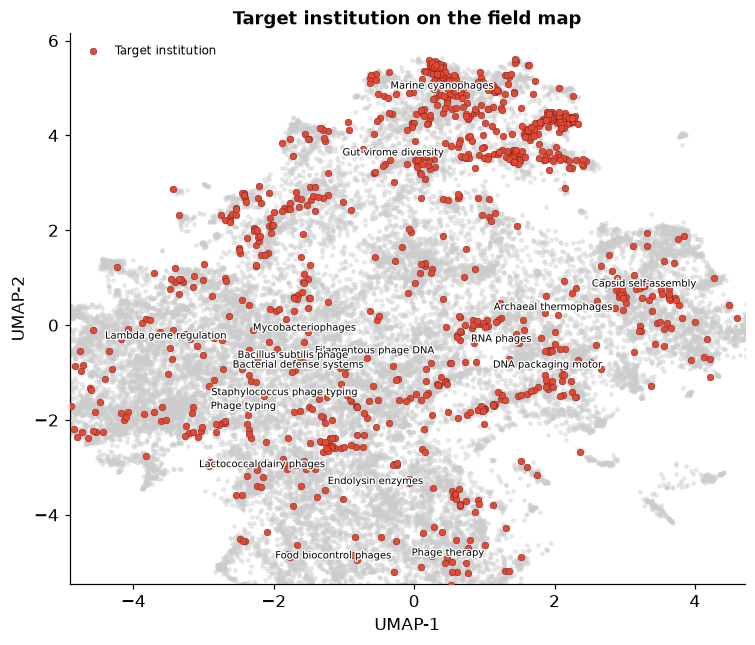

In [14]:
if n_inst > 0:
    # (1) 地図に機関論文を重ねる。
    fig, ax = plt.subplots(figsize=(7,6))
    ax.scatter(works_df['x'], works_df['y'], s=5, c='0.8', alpha=0.35, rasterized=True)
    inst_papers = works_df[works_df['is_inst']]
    ax.scatter(inst_papers['x'], inst_papers['y'], s=20, color='#E24A33', edgecolors='#3d0814',
               linewidth=0.2, label='Target institution', zorder=5)
    for c in top:
        s = works_df[works_df['cluster'] == c]
        ax.annotate(names[c], (s['x'].median(), s['y'].median()), fontsize=6.5, ha='center', va='center', zorder=6,
                    path_effects=[patheffects.withStroke(linewidth=1.8, foreground='white')])
    ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi); ax.grid(False)
    ax.set_title('Target institution on the field map'); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.legend(loc='upper left', fontsize=8)
    fig.tight_layout(); fig.savefig(f'{OUT_DIR}/04_institution_map.pdf'); plt.show()


**結果の見方**: 赤い点が対象機関の論文です。特定のサブ分野（色の領域）に赤が集中していれば、そこがその機関の得意テーマ。地図全体に散っていれば、幅広く手がけていると読めます。

### 機関の強みを3指標で定量化

強みを3つの角度から数値化します。

- **(1) クラスタ別シェア** = 機関の論文数 ÷ そのサブ分野の総論文数。件数の絶対量ではなく**割合**で見るので、大きな分野に埋もれた相対的な強みが出ます。
- **(2) 年次推移**（積み上げ面）: 上位サブ分野での機関の活動量が時間とともにどう変わったか。
- **(3) 成長率** = 後半(2015–2024) − 前半(2005–2014) の論文数の差。プラスは伸長、マイナスは縮小。

,works,inst,share,name
cluster,,,,
19,657,159,0.242009,Giant viruses
8,1293,117,0.090487,Marine cyanophages
11,941,74,0.078640,Lactococcal dairy phages
18,700,41,0.058571,Small RNAs
3,1861,106,0.056959,Gut virome diversity
14,895,46,0.051397,Archaeal thermophages
12,1133,54,0.047661,DNA packaging motor
10,899,41,0.045606,Bacterial defense systems
21,508,22,0.043307,Outer membrane proteins


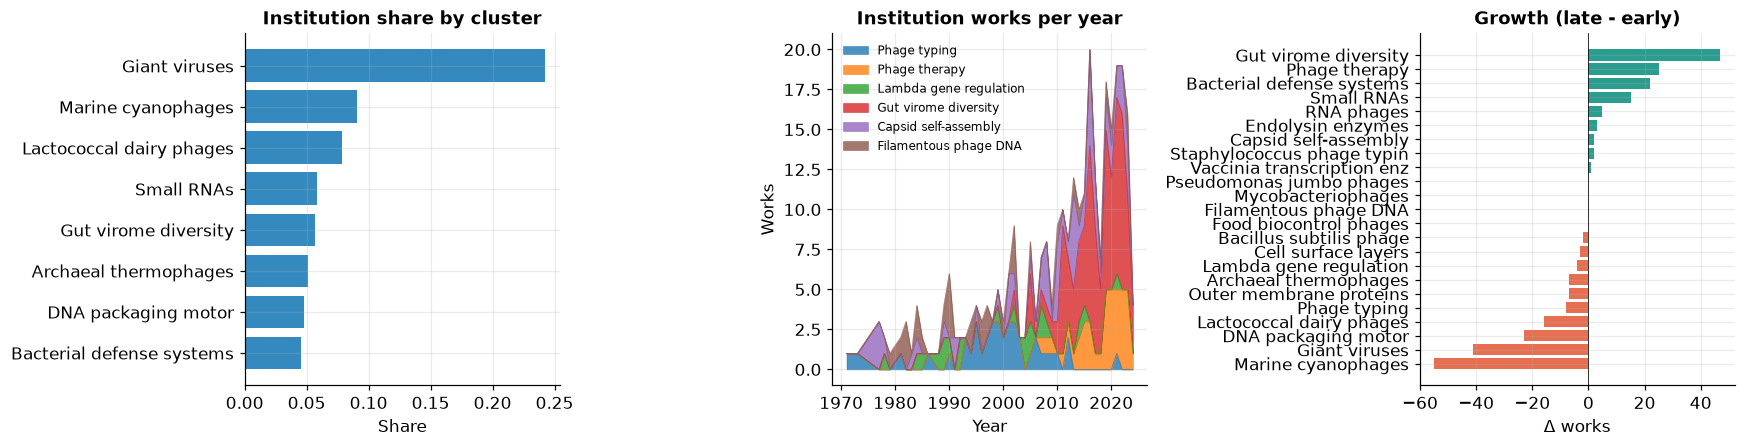

In [15]:
if n_inst > 0:
    clustered = works_df[works_df['cluster'] >= 0]
    # (2) クラスタ別シェア = 機関の論文数 / クラスタの論文数。
    share = clustered.groupby('cluster').agg(works=('id', 'count'), inst=('is_inst', 'sum'))
    share['share'] = share['inst'] / share['works']
    share['name'] = [names.get(c, str(c)) for c in share.index]
    display(share.sort_values('share', ascending=False).head(10))

    # (3) 年次推移（積み上げ面）と成長率（前半 vs 後半の差）。
    top6 = kw_df.head(6)['cluster'].astype(int).tolist()
    pivot = (clustered[clustered['is_inst'] & clustered['cluster'].isin(top6)]
             .groupby(['publication_year', 'cluster']).size().unstack(fill_value=0).sort_index())
    pivot.columns = [names.get(c, str(c)) for c in pivot.columns]
    early = clustered[clustered['is_inst'] & clustered['publication_year'].between(2005, 2014)]['cluster'].value_counts()
    late = clustered[clustered['is_inst'] & clustered['publication_year'].between(2015, 2024)]['cluster'].value_counts()
    growth = (late - early.reindex(late.index, fill_value=0)).fillna(late).sort_values()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
    ts = share.sort_values('share').tail(8)
    axes[0].barh(ts['name'].str.slice(0, 26), ts['share'], color='#348ABF')
    axes[0].set_title('Institution share by cluster'); axes[0].set_xlabel('Share')
    if not pivot.empty:
        pivot.plot.area(ax=axes[1], alpha=0.8, linewidth=0.4); axes[1].legend(fontsize=8, loc='upper left')
    axes[1].set_title('Institution works per year'); axes[1].set_xlabel('Year'); axes[1].set_ylabel('Works')
    axes[2].barh([names.get(c, str(c))[:26] for c in growth.index], growth.values,
                 color=['#2a9d8f' if v > 0 else '#e76f51' for v in growth.values])
    axes[2].axvline(0, color='black', linewidth=0.5)
    axes[2].set_title('Growth (late - early)'); axes[2].set_xlabel('Δ works')
    fig.tight_layout(); fig.savefig(f'{OUT_DIR}/04_institution_strengths.pdf'); plt.show()


**結果の見方**: 左＝シェアの高いサブ分野ほど「この機関が相対的に強い」テーマ。中央＝どの時期にどのテーマを伸ばしたか。右＝緑が近年伸びている、赤が退いているテーマ（`0` が基準線）。論文数の少ない機関では棒が疎になる点に注意してください。

## まとめ

- `works.parquet` を読み、**引用ネットワーク → Leiden コミュニティ → 埋め込み → UMAP 俯瞰地図**という流れで、バクテリオファージ研究の全体地図を作りました。
- **引用のつながり（ネットワーク）** と **内容の近さ（テキスト）** の2つの見方を同じ地図上で並べ、両者のズレ＝「手法は共有しつつ別々に引用される領域」を読み取りました。
- サブ分野の GPT 要約、特定機関のハイライト・シェア・年次推移・成長率まで分析しました。
- `NAME` を `'qc'` にすれば、同じコードで量子情報分野の地図が得られます。